In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import chi2
from sklearn.cluster import KMeans
from pandas.api.types import CategoricalDtype
from datetime import datetime

from imblearn.over_sampling import SMOTE


In [ ]:
# Loading outlier functions
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"Outliers in {column}: {len(outliers)} rows out of {df.shape[0]} ({len(outliers)*100/df.shape[0]:.2f}%)")
    return outliers

def remove_outliers(df, columns):
    df_cleaned = df.copy()

    for column in columns:
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]

    print(f"Total removed outliers: {len(df) - len(df_cleaned)} across {columns}")
    return df_cleaned

def data_summary(df):
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'missing_values': df.isnull().sum(),
        'unique_values': df.nunique(),
        'Number of entries': df.shape[0]
    })
    duplicates = df.duplicated().sum()
    print(f"Total Duplicates: {duplicates}")
    return summary

### Cleaning Agent Dataset


In [ ]:
os.chdir("/content/drive/My Drive/NUS_DATATHON_CAT_A_68")

In [ ]:
df_agent = pd.read_parquet("nus_agent_info_df.parquet")

In [ ]:
def data_summary(df):
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'missing_values': df.isnull().sum(),
        'unique_values': df.nunique(),
        'Number of entries': df.shape[0]
    })
    duplicates = df.duplicated().sum()
    print(f"Total Duplicates: {duplicates}")
    return summary

# Exploratory Data Analysis

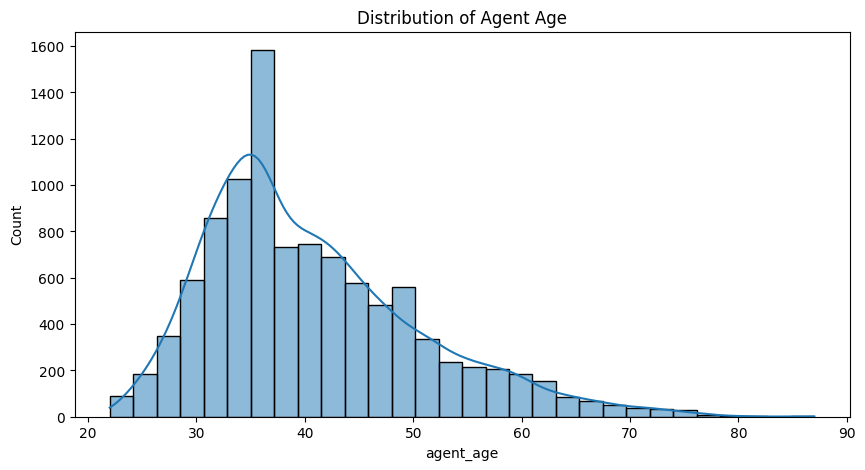

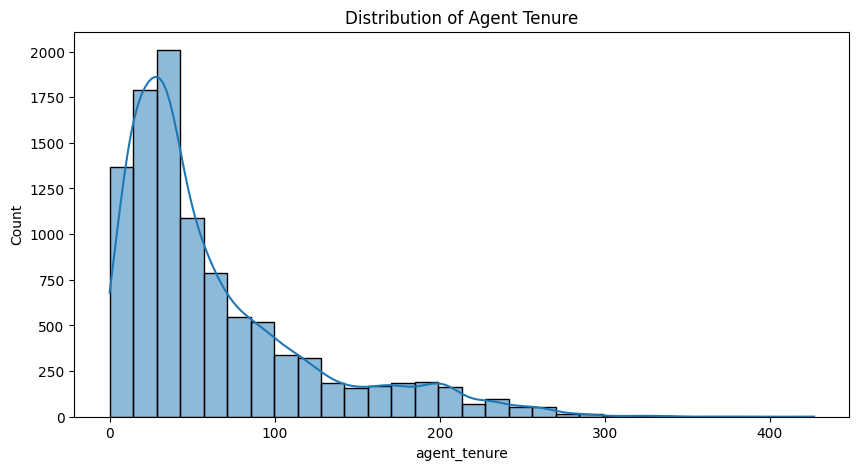

In [ ]:
# Agent Age Distribution
plt.figure(figsize=(10,5))
sns.histplot(df_agent['agent_age'], bins=30, kde=True)
plt.title("Distribution of Agent Age")
plt.show()

# Agent Tenure Distribution
plt.figure(figsize=(10,5))
sns.histplot(df_agent['agent_tenure'], bins=30, kde=True)
plt.title("Distribution of Agent Tenure")
plt.show()

In [ ]:
def preprocess_agent_data(df_agent):
    # Convert agent tenure from months to years
    df_agent["agent_tenure"] = df_agent["agent_tenure"] / 12

    # Clean agent number
    df_agent["agntnum"] = df_agent["agntnum"].str.replace("AIN:", "", regex=True)
    df_agent["agntnum"] = df_agent["agntnum"].astype(int)

    # Explode 'agent_product_expertise' into separate rows
    df_agent = df_agent.explode("agent_product_expertise")

    # Convert expertise values to integers
    df_agent['agent_product_expertise'] = df_agent['agent_product_expertise'].astype(str)
    df_agent['agent_product_expertise'] = df_agent['agent_product_expertise'].str.replace('prod_', '', regex=True)
    df_agent['agent_product_expertise'] = df_agent['agent_product_expertise'].astype(int)

    # Drop missing values
    df_agent = df_agent.dropna()

    # Remove invalid rows where tenure exceeds age or age is negative
    df_agent = df_agent[(df_agent["agent_tenure"] <= df_agent["agent_age"]) & (df_agent["agent_age"] >= 0)]

    # Drop duplicate rows
    df_agent = df_agent.drop_duplicates()

    # Drop unnecessary column
    df_agent.drop(["pct_SX0_unknown"], axis=1, inplace=True)

    # Standardize agent gender values
    agent_gender_category = CategoricalDtype(categories=["Male", "Female"])
    df_agent.loc[df_agent["agent_gender"] == "M", 'agent_gender'] = "Male"
    df_agent.loc[df_agent["agent_gender"] == "F", 'agent_gender'] = "Female"
    df_agent = df_agent[df_agent["agent_gender"] != "U"]  # Drop unknown gender values
    df_agent.loc[:, "agent_gender"] = df_agent["agent_gender"].astype(agent_gender_category)

    # Standardize agent marital status values
    agent_marital_category = CategoricalDtype(categories=["Married", "Divorced", "Single"])
    df_agent.loc[df_agent["agent_marital"] == "M", 'agent_marital'] = "Married"
    df_agent.loc[df_agent["agent_marital"] == "D", 'agent_marital'] = "Divorced"
    df_agent.loc[df_agent["agent_marital"] == "S", 'agent_marital'] = "Single"
    df_agent = df_agent[~df_agent["agent_marital"].isin(["U", "W"]) ]  # Drop unknown and widowed statuses
    df_agent["agent_marital"] = df_agent["agent_marital"].astype(agent_marital_category)

    # Convert categorical columns to category type
    df_agent["cluster"] = df_agent["cluster"].astype("category")
    df_agent["agent_product_expertise"] = df_agent["agent_product_expertise"].astype("category")

    # One-hot encoding for categorical features
    agent_cat_features = ["agent_gender", "agent_marital", "agent_product_expertise"]
    df_agent_encoded = pd.get_dummies(df_agent, columns=agent_cat_features, drop_first=True)

    df_agent_encoded["agentPctCustAge01_29"] = df_agent_encoded["pct_AG01_lt20"] + df_agent_encoded["pct_AG02_20to24"] + df_agent_encoded["pct_AG03_25to29"]
    df_agent_encoded["agentPctCustAge30_34"] = df_agent_encoded["pct_AG04_30to34"]
    df_agent_encoded["agentPctCustAge35_39"] = df_agent_encoded["pct_AG05_35to39"]
    df_agent_encoded["agentPctCustAge40_44"] = df_agent_encoded["pct_AG06_40to44"]
    df_agent_encoded["agentPctCustAge45_49"] = df_agent_encoded["pct_AG07_45to49"]
    df_agent_encoded["agentPctCustAge50_59"] = df_agent_encoded["pct_AG08_50to54"]
    df_agent_encoded["agentPctCustAge55_99"] = df_agent_encoded["pct_AG09_55to59"] + df_agent_encoded["pct_AG10_60up"]

    del df_agent_encoded["pct_AG01_lt20"]
    del df_agent_encoded["pct_AG02_20to24"]
    del df_agent_encoded["pct_AG03_25to29"]
    del df_agent_encoded["pct_AG04_30to34"]
    del df_agent_encoded["pct_AG05_35to39"]
    del df_agent_encoded["pct_AG06_40to44"]
    del df_agent_encoded["pct_AG07_45to49"]
    del df_agent_encoded["pct_AG08_50to54"]
    del df_agent_encoded["pct_AG09_55to59"]
    del df_agent_encoded["pct_AG10_60up"]

    return df_agent_encoded

In [ ]:
df_agent_encoded = preprocess_agent_data(df_agent)

In [ ]:
data_summary(df_agent_encoded)

Total Duplicates: 0


,dtype,missing_values,unique_values,Number of entries
agntnum,int64,0,8959,27283
agent_age,float64,0,62,27283
agent_tenure,float64,0,294,27283
cnt_converted,float64,0,1817,27283
annual_premium_cnvrt,float64,0,8767,27283
pct_lapsed,float64,0,11,27283
pct_cancel,float64,0,4930,27283
pct_inforce,float64,0,4995,27283
pct_prod_0_cnvrt,float64,0,109,27283
pct_prod_1_cnvrt,float64,0,584,27283


# Cleaning Policy Dataset

In [ ]:
df_policy = pd.read_parquet("nus_policy_info_df.parquet")

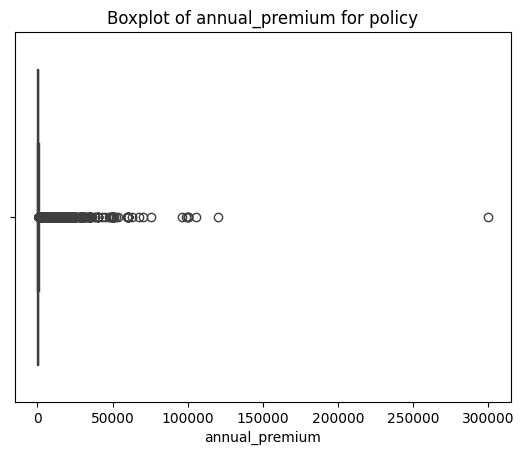

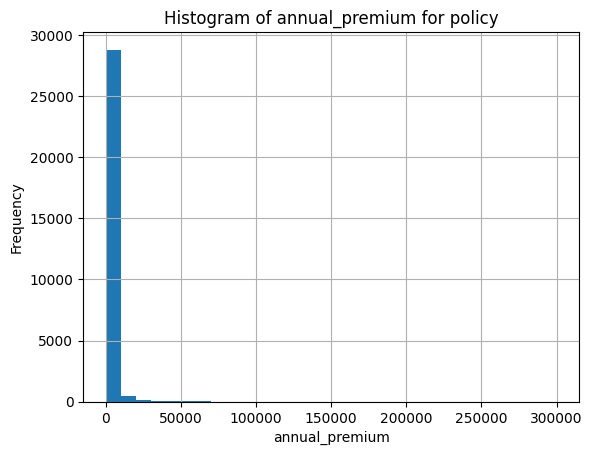

In [ ]:
# Boxplot for annual premium (numerical)
sns.boxplot(x=df_policy['annual_premium'])
plt.title('Boxplot of annual_premium for policy')
plt.show()

# histogram for annual premium (numerical)
df_policy['annual_premium'].hist(bins=30)
plt.title('Histogram of annual_premium for policy')
plt.xlabel('annual_premium')
plt.ylabel('Frequency')
plt.show()

In [ ]:
def preprocess_policy_data(policy_df):
    # Remove irrelevant columns
    policy_df.drop(['flg_main', 'flg_inforce', 'flg_cancel', 'flg_expire',
                    'flg_converted', 'flg_rider', 'flg_lapsed'], axis=1, inplace=True)


    # Standardize age group labels
    age_mapping = {
        "AG01_lt20": "<20", "AG02_20to24": "20-24", "AG03_25to29": "25-29",
        "AG04_30to34": "30-34", "AG05_35to39": "35-39", "AG06_40to44": "40-44",
        "AG07_45to49": "45-49", "AG08_50to54": "50-54", "AG09_55to59": "55-59",
        "AG10_60up": ">60"
    }
    policy_df["cust_age_at_purchase_grp"] = policy_df["cust_age_at_purchase_grp"].replace(age_mapping)
    age_categories = CategoricalDtype(categories=age_mapping.values())
    policy_df["cust_age_at_purchase_grp"] = policy_df["cust_age_at_purchase_grp"].astype(age_categories)

    # Standardize tenure group labels
    tenure_mapping = {
        "TNR2_lt1yr": "<1", "TNR3_1to4yr": "1-4", "TNR4_4to8yr": "4-8", "TNR5_8yrup": ">8"
    }
    policy_df["cust_tenure_at_purchase_grp"] = policy_df["cust_tenure_at_purchase_grp"].replace(tenure_mapping)
    tenure_categories = CategoricalDtype(categories=tenure_mapping.values())
    policy_df["cust_tenure_at_purchase_grp"] = policy_df["cust_tenure_at_purchase_grp"].astype(tenure_categories)
    policy_df.rename(columns={'cust_tenure_at_purchase_grp': 'cust_tenure_at_purchase_grp_in_years'}, inplace=True)

    # Standardize product group labels
    policy_df["product_grp"] = policy_df["product_grp"].str.replace("PG:", "", regex=True).astype(int)

    # Standardize product labels
    policy_df["product"] = policy_df["product"].str.replace("prod_", "", regex=True).astype(int)

    # Convert identifiers to integers
    policy_df["chdrnum"] = policy_df["chdrnum"].str.replace("PID:", "", regex=True).astype(int)
    policy_df["agntnum"] = policy_df["agntnum"].str.replace("AIN:", "", regex=True).astype(int)
    policy_df["secuityno"] = policy_df["secuityno"].str.replace("CIN:", "", regex=True).astype(int)

    # One-hot encoding for nominal features
    policy_cat_features = ["product", "product_grp"]
    policy_df = pd.get_dummies(policy_df, columns=policy_cat_features, drop_first=True)

    # Label encode ordinal features
    le = LabelEncoder()
    policy_df["cust_age_at_purchase_grp"] = le.fit_transform(policy_df["cust_age_at_purchase_grp"].astype(str))
    policy_df["cust_tenure_at_purchase_grp_in_years"] = le.fit_transform(policy_df["cust_tenure_at_purchase_grp_in_years"].astype(str))

    df_policy["occdate"] = pd.to_datetime(df_policy["occdate"])
    today = datetime.today()
    policy_df['policy_year'] = df_policy['occdate'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))
    del df_policy["occdate"]

    return policy_df

In [ ]:
df_policy_encoded = preprocess_policy_data(df_policy)

# Cleaning Client Dataset

In [ ]:
df_client = pd.read_parquet("nus_client_info_df.parquet")

In [ ]:
def preprocess_client_data(df_client):
    # Drop missing values
    df_client = df_client.dropna()

    # Categorical datatype conversions
    sex_category = CategoricalDtype(categories=["M", "F"])
    df_client["cltsex"] = df_client["cltsex"].astype(sex_category)

    race_category = CategoricalDtype(categories=["Chinese", "Malay", "Indian", "Others"])
    df_client["race_desc_map"] = df_client["race_desc_map"].astype(race_category)

    marital_category = CategoricalDtype(categories=["Single", "Married", "Divorced"])
    df_client.loc[df_client["marryd"] == "D", "marryd"] = "Divorced"
    df_client.loc[df_client["marryd"] == "M", "marryd"] = "Married"
    df_client.loc[df_client["marryd"] == "S", "marryd"] = "Single"
    df_client = df_client[~df_client["marryd"].isin(["P", "U", "W"])]
    df_client["marryd"] = df_client["marryd"].astype(marital_category)

    # Household Size
    household_mapping = {
        "HH1_lt40": "<40", "HH2_40to80": "40-80", "HH3_80to100": "80-100",
        "HH4_100to120": "100-120", "HH5_120up": ">120"
    }
    df_client = df_client[df_client["household_size_grp"] != "HH0_missing"]
    df_client["household_size_grp"] = df_client["household_size_grp"].replace(household_mapping)
    household_size_category = CategoricalDtype(categories=list(household_mapping.values()))
    df_client["household_size_grp"] = df_client["household_size_grp"].astype(household_size_category)

    # Family Size
    family_mapping = {
        "FS1_lt20": "<20", "FS2_20to40": "20-40", "FS3_40to60": "40-60",
        "FS4_60to80": "60-80", "FS5_80up": ">80"
    }
    df_client["family_size_grp"] = df_client["family_size_grp"].replace(family_mapping)
    family_size_category = CategoricalDtype(categories=list(family_mapping.values()))
    df_client["family_size_grp"] = df_client["family_size_grp"].astype(family_size_category)

    # Convert economic status to integer
    df_client["economic_status"] = df_client["economic_status"].astype(int)

    # Convert identifier columns to integers
    df_client["secuityno"] = df_client["secuityno"].str.replace("CIN:", "", regex=True).astype(int)
    df_client["cltpcode"] = df_client["cltpcode"].astype(int)

    # Calculate age from date of birth
    df_client["cltdob"] = pd.to_datetime(df_client["cltdob"])
    today = datetime.today()
    df_client["age"] = df_client["cltdob"].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))

    # Rename columns for consistency
    rename_columns = {
        "cltsex": "client_sex",
        "cltdob": "client_dob",
        "marryd": "client_marital_status",
        "race_desc_map": "client_race",
        "cltpcode": "client_postal_code",
        "age": "client_age",
        "economic_status": "client_economic_status",
        "household_size_grp": "client_household_size",
        "family_size_grp": "client_family_size"
    }
    df_client.rename(columns=rename_columns, inplace=True)

    # Drop unnecessary columns
    df_client.drop(["client_dob", "client_postal_code"], axis=1, inplace=True)

    # One-hot encoding for nominal features
    client_cat_features = ["client_sex", "client_marital_status", "client_race"]
    df_client = pd.get_dummies(df_client, columns=client_cat_features, drop_first=True)

    # Label encode ordinal features
    le = LabelEncoder()
    df_client["client_household_size"] = le.fit_transform(df_client["client_household_size"].astype(str))
    df_client["client_family_size"] = le.fit_transform(df_client["client_family_size"].astype(str))

    return df_client


In [ ]:
df_client_encoded = preprocess_client_data(df_client)

<ipython-input-53-07719420defb>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_client["cltsex"] = df_client["cltsex"].astype(sex_category)
<ipython-input-53-07719420defb>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_client["race_desc_map"] = df_client["race_desc_map"].astype(race_category)


# Merging of datasets

In [ ]:
df_merged = df_policy_encoded.merge(df_agent_encoded, on="agntnum", how="left")
df_merged = df_merged.merge(df_client_encoded, on="secuityno", how="left")

In [ ]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"Outliers in {column}: {len(outliers)} rows")
    return outliers

def remove_outliers(df, columns):
    df_cleaned = df.copy()

    for column in columns:
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]

    print(f"Total removed outliers: {len(df) - len(df_cleaned)} across {columns}")
    return df_cleaned

In [ ]:
def select_features(df):
    selected_columns = [
        "chdrnum", "agntnum", "secuityno", "cust_age_at_purchase_grp", "cust_tenure_at_purchase_grp_in_years",
        "client_household_size", "client_family_size", "client_age", "client_sex_F", "client_marital_status_Married",
        "client_marital_status_Divorced", "client_race_Indian", "client_race_Malay", "client_race_Others",
        "client_economic_status", "cluster"
    ]
    df_selected = df[selected_columns].drop_duplicates()
    return df_selected


In [ ]:
def clean_merged_data(df):
    # Drop missing values
    df = df.dropna()

    # Detect and remove outliers
    interested_cols = ["client_age", "client_household_size"]

    for col in interested_cols:
        detect_outliers_iqr(df, col)
    df = remove_outliers(df, interested_cols)

    # Select features
    df = select_features(df)

    return df

In [ ]:
df_merged = rename_columns(df_merged)
df_merged = clean_merged_data(df_merged)

Outliers in client_age: 84 rows
Outliers in client_household_size: 0 rows
Total removed outliers: 84 across ['client_age', 'client_household_size']


# Model Building

In [ ]:
def train_test_split_data(df, features, target, test_size=0.2, random_state=42):
    """
    Splits the dataset into train and test sets.

    Parameters:
    df (pd.DataFrame): The dataset containing features and target variable.
    features (list): List of feature column names.
    target (str): The target column name.
    test_size (float): Proportion of data to be used as the test set.
    random_state (int): Random seed for reproducibility.

    Returns:
    X_train, X_test, y_train, y_test: Train and test sets.
    """
    X_train, X_test, y_train, y_test = train_test_split(df[features], df[target],
                                                        test_size=test_size,
                                                        random_state=random_state,
                                                        stratify=df[target])
    return X_train, X_test, y_train, y_test

In [ ]:
def apply_smote(X_train, y_train, random_state=42):
    """
    Applies SMOTE to the training set to handle class imbalance.

    Parameters:
    X_train (pd.DataFrame): Training feature set.
    y_train (pd.Series): Training target set.
    random_state (int): Random seed for reproducibility.

    Returns:
    X_train_resampled, y_train_resampled: Resampled training set.
    """
    smote = SMOTE(random_state=random_state)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    return X_train_resampled, y_train_resampled

In [ ]:
def train_val_split(X_train_resampled, y_train_resampled, val_size=0.125, random_state=42):
    """
    Splits the resampled training data into training and validation sets.

    Parameters:
    X_train_resampled (pd.DataFrame): Resampled training feature set.
    y_train_resampled (pd.Series): Resampled training target set.
    val_size (float): Proportion of training data to be used as validation set.
    random_state (int): Random seed for reproducibility.

    Returns:
    X_train_final, X_val, y_train_final, y_val: Final training and validation sets.
    """
    X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_resampled, y_train_resampled,
                                                                  test_size=val_size,
                                                                  random_state=random_state,
                                                                  stratify=y_train_resampled)
    return X_train_final, X_val, y_train_final, y_val


In [ ]:
def build_model(df, target="cluster"):
    """
    Builds a RandomForestClassifier model to predict agent segment assignment.

    Parameters:
    df (pd.DataFrame): The preprocessed dataset containing features and target variable.
    target (str): The target column name (default is "cluster").

    Returns:
    dict: A dictionary containing the trained model, dataset splits, and test set.
    """

    # Define features
    features = [
        "cust_age_at_purchase_grp", "cust_tenure_at_purchase_grp_in_years",
        "client_household_size", "client_family_size", "client_age", "client_sex_F",
        "client_marital_status_Married", "client_marital_status_Divorced",
        "client_race_Indian", "client_race_Malay", "client_race_Others",
        "client_economic_status"
    ]

    # Step 1: Train-Test Split (80-20)
    X_train, X_test, y_train, y_test = train_test_split_data(df, features, target)

    # Step 2: Apply SMOTE to handle class imbalance
    X_train_resampled, y_train_resampled = apply_smote(X_train, y_train)

    # Step 3: Train-Validation Split (Train: 70%, Validation: 10%)
    X_train_final, X_val, y_train_final, y_val = train_val_split(X_train_resampled, y_train_resampled)

    # Step 4: Train a RandomForestClassifier
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42,
                                      min_samples_split=2, min_samples_leaf=1)
    rf_model.fit(X_train_final, y_train_final)

    return {
        "model": rf_model,
        "X_train": X_train_final, "y_train": y_train_final,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test
    }

In [ ]:
def predict_and_evaluate(df):
    """
    Builds the model, makes predictions on the validation set,
    and prints a classification report.

    Parameters:
    df (pd.DataFrame): The dataset used for training the model.

    Returns:
    y_pred (np.array): The model predictions on the test set.
    """

    # Train the model and get dataset splits
    model_results = build_model(df)

    # Extract trained model and validation data
    model = model_results["model"]
    X_test = model_results["X_test"]
    y_test = model_results["y_test"]

    # Make predictions
    y_pred = model.predict(X_test)

    #Print the classification report
    print("Classification Report on Validation Data:")
    print(classification_report(y_test, y_pred))

    return y_pred

In [ ]:
predict_and_evaluate(df_merged)

Classification Report on Validation Data:
              precision    recall  f1-score   support

           0       0.58      0.47      0.52        98
           1       0.63      0.71      0.67      1621
           2       0.45      0.31      0.36       199
           3       0.43      0.40      0.41       134
           4       0.60      0.60      0.60       303
           5       0.58      0.56      0.57      1079
           6       0.63      0.61      0.62       525
           7       0.53      0.50      0.52       343
           8       0.46      0.42      0.44       432
           9       0.61      0.62      0.61       245

    accuracy                           0.59      4979
   macro avg       0.55      0.52      0.53      4979
weighted avg       0.58      0.59      0.58      4979



array([1, 5, 5, ..., 2, 5, 1], dtype=int32)

## Hyper Parameter Tuning

In [ ]:
def hyperparameter_tuning(X_train, y_train, n_iter=10, cv=3, random_state=42):
    """
    Performs hyperparameter tuning on a RandomForestClassifier using RandomizedSearchCV.

    Parameters:
    X_train (pd.DataFrame): Training feature set.
    y_train (pd.Series): Training target labels.
    n_iter (int): Number of iterations for RandomizedSearchCV (default=10).
    cv (int): Number of cross-validation folds (default=3).
    random_state (int): Random seed for reproducibility (default=42).

    Returns:
    RandomForestClassifier: The best tuned model.
    """

    # Define hyperparameter grid
    param_grid_rf = {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }

    # Perform RandomizedSearchCV
    rf_random = RandomizedSearchCV(
        RandomForestClassifier(random_state=random_state),
        param_distributions=param_grid_rf,
        n_iter=n_iter,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        random_state=random_state
    )

    rf_random.fit(X_train, y_train)

    # Print Best Parameters
    print("Best Random Forest Parameters:", rf_random.best_params_)

    return rf_random.best_estimator_  # Return the best trained model

## Feature Importance

In [ ]:
def plot_feature_importance(model):
    """
    Plots the feature importance of a trained RandomForestClassifier model.

    Parameters:
    model (RandomForestClassifier): The trained RandomForestClassifier model.
    """

    # Extract Feature Importance
    importances = model.feature_importances_
    features_used = model.feature_names_in_

    # Create DataFrame for visualization
    feature_importance = pd.DataFrame({"Feature": features_used, "Importance": importances})
    feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

    # Plot Feature Importance
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance)
    plt.title("Feature Importance - Random Forest")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.show()


In [ ]:

model = build_model(df_merged)

In [ ]:
from sklearn.model_selection import cross_val_score
# Perform Cross-Validation for Random Forest
cross_val_scores = cross_val_score(rf_model_final, X_train_final, y_train_final, cv=5, scoring='accuracy')
print("Cross-Validation Scores for Random Forest:", cross_val_scores)
print("Mean Cross-Validation Accuracy:", np.mean(cross_val_scores))

In [ ]:
def addChosenCluster(df_features, df_answers):
  ''''
  df_features = df_merged[features]
  df_answers = df_merged["agntnum"]
  '''
  df_cluster_chosen = df_features.copy()
  df_cluster_chosen["predicted_cluster"] = rf_model_final.predict(df_features)
  df_cluster_chosen["agentID"] = df_merged["agntnum"]
  return df_cluster_chose

In [ ]:
def splitClusters(df):
  cluster_dataset = [];
  for i in range(0,10):
    list.append(df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == i])
  return cluster_dataset

In [ ]:
df_predicted_cluster = addChosenCluster(df_merged[features], df_merged["agntnum"])
df_p

In [ ]:
 y_pred_test = rf_model_final.predict(X_test)
 print(classification_report(y_test, y_pred_test))

In [ ]:
df_cluster_chosen = df_merged[features].copy()
df_cluster_chosen["predicted_cluster"] = rf_model_final.predict(df_merged[features])
df_cluster_chosen["agentID"] = df_merged["agntnum"]

df_cluster0 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 0]
df_cluster1 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 1]
df_cluster2 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 2]
df_cluster3 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 3]
df_cluster4 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 4]
df_cluster5 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 5]
df_cluster6 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 6]
df_cluster7 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 7]
df_cluster8 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 8]
df_cluster9 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 9]

df_sizes = pd.DataFrame({
    'DataFrame': ['df_cluster0', 'df_cluster1','df_cluster2','df_cluster3','df_cluster4',
                  'df_cluster5','df_cluster6','df_cluster7','df_cluster8','df_cluster9'],
    'Num Entries': [df_cluster0.shape[0], df_cluster1.shape[0],df_cluster2.shape[0],
                    df_cluster3.shape[0],df_cluster4.shape[0],df_cluster5.shape[0],
                    df_cluster6.shape[0],df_cluster7.shape[0],df_cluster8.shape[0],
                    df_cluster9.shape[0]]
})
df_sizes

In [ ]:
agentID_customer_features = ['cust_purchase_age','cust_purchase_tenure','cust_postal_code', 'cust_hsehold_size',
       'cust_economic_status', 'cust_family_size', 'cust_age',
       'cust_fam_size_grp_20-40', 'cust_fam_size_grp_40-60',
       'cust_fam_size_grp_60-80', 'cust_fam_size_grp_<20',
       'cust_fam_size_grp_>80', 'cust_gender_M', 'cust_marital_status_Married',
       'cust_marital_status_Single', 'cust_marital_status_Unknown',
       'cust_race_Indian', 'cust_race_Malay', 'cust_race_Others',
       'agent_gender_M', 'agent_marital_Married', 'agent_marital_Single',
       'agent_marital_Unknown',"agentID"]
df_agentID_custFeatures = df_merged_final[agentID_customer_features]

In [ ]:
# Use first random forest model to predict cluster, then use it to train
# 2nd random forest model to predict agentID
df_cluster_chosen = df_agentID_custFeatures.copy()
df_cluster_chosen["predicted_cluster"] = model.predict(df_agentID_custFeatures.loc[:, df_agentID_custFeatures.columns != "agentID"])

df_cluster0 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 0]
df_cluster1 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 1]
df_cluster2 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 2]
df_cluster3 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 3]
df_cluster4 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 4]
df_cluster5 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 5]
df_cluster6 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 6]
df_cluster7 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 7]
df_cluster8 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 8]
df_cluster9 = df_cluster_chosen[df_cluster_chosen["predicted_cluster"] == 9]

df_sizes = pd.DataFrame({
    'DataFrame': ['df_cluster0', 'df_cluster1','df_cluster2','df_cluster3','df_cluster4',
                  'df_cluster5','df_cluster6','df_cluster7','df_cluster8','df_cluster9'],
    'Num Entries': [df_cluster0.shape[0], df_cluster1.shape[0],df_cluster2.shape[0],
                    df_cluster3.shape[0],df_cluster4.shape[0],df_cluster5.shape[0],
                    df_cluster6.shape[0],df_cluster7.shape[0],df_cluster8.shape[0],
                    df_cluster9.shape[0]]
})
df_sizes

In [ ]:
# Choose agent (cluster 1,5,6,8 most common)
df_cluster1_agentID = df_cluster8["agentID"]  # change this if change cluster
remove_predictors2 = ["agentID"]
df_cluster1_predictors = df_cluster8.loc[:, ~df_cluster1.columns.isin(remove_predictors2)] # change this if change cluster


from sklearn.model_selection import train_test_split
c1_x_train, c1_x_test, c1_y_train, c1_y_test = train_test_split(df_cluster1_predictors, df_cluster1_agentID, test_size = 0.2, random_state = 42)
c1_x_train, c1_x_val, c1_y_train, c1_y_val= train_test_split(c1_x_train, c1_y_train, test_size = 0.125, random_state = 42)

In [ ]:
# Just Run once to get the best data
'''
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    "n_estimators": [10, 30, 50, 70, 100],
    "max_depth": [10, 20, 30, 40, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}

rf_random = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions=param_grid_rf, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
rf_random.fit(c1_x_train, c1_y_train)
print(rf_random.score(c1_x_val, c1_y_val)) # 0.3137724550898204
print(rf_random.score(c1_x_test, c1_y_test)) # 0.33871932974266905

print("Best Random Forest Parameters:", rf_random.best_params_)
'''

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

c1_model = RandomForestClassifier(n_estimators=100, min_samples_split = 1, min_samples_leaf=1, max_depth = 20)
c1_model.fit(c1_x_train, c1_y_train)
c1_y_test_pred = c1_model.predict(c1_x_test)
c1_y_val_pred = c1_model.predict(c1_x_val)
print(c1_model.score(c1_x_val, c1_y_val))   # validating accuracy
print(c1_model.score(c1_x_test, c1_y_test)) # testing accuracy
df_cluster1_predictors

# Cluster chosen               5           8          1
# Validating Accuracy        0.4275      0.3532
# Testing Accuracy           0.4137      0.3043

In [ ]:
from sklearn.metrics import confusion_matrix
c1_cm = confusion_matrix(c1_y_test, c1_y_test_pred)

plt.figure(figsize = (14,7))
sns.heatmap(c1_cm, annot = True, fmt=".0f")
plt.xlabel('Predicted')
plt.ylabel('Truth')